# Data Pipeline for Magnetic Field Prediction

This chapter develops a comprehensive data pipeline for generating training data using **FEMM (Finite Element Method Magnetics)** for three distinct electromagnetic problems. We explore the theoretical foundations of sampling, feature engineering, and physics-informed data generation that enable robust deep learning models for magnetic field prediction.

## Learning Objectives

After completing this notebook, you will understand:

- **Sampling Theory**: Mathematical foundations of experimental design and parameter space exploration
- **Latin Hypercube Sampling**: Optimal space-filling design for multidimensional parameter spaces
- **Feature Engineering**: Mathematical transformation of physical parameters for neural network inputs
- **FEMM Integration**: Theory and practice of finite element method integration for data generation
- **Multi-geometry Data Generation**: Strategies for diverse electromagnetic problems
- **Data Validation**: Quality assurance and physics consistency checking

## Electromagnetic Problems Overview

This data pipeline generates training data for three fundamental electromagnetic problems of increasing complexity:

1. **Simple Coil in Air** - Basic electromagnetic problem with analytical validation
2. **Transformer** - Multi-material problem with magnetic core (M19 silicon steel) and windings 
3. **IPM Motor** - Complex rotating machine with permanent magnets and non-linear materials

The complete dataset consists of **45,000 samples** generated using **Latin Hypercube Sampling**:
- Training: 30,000 samples
- Validation: 10,000 samples
- Test: 5,000 samples

All three problems are parametrized and simulated using FEA software. Material properties including non-linear B-H relations are incorporated from the material library.

## Problem 1: Simple Coil in Air

A simple coil made of copper is located inside an airbox with fixed dimensions (height = 160mm, width = 160mm). The parametric design varies:

**Variable Parameters**:
- **Coil Radius**: $3mm \leq R \leq 15mm$
- **Coil Center Position**: $(x_c, y_c)$ adjusted to keep coil inside airbox
- **Coil Current**: $5A \leq I \leq 15A$

**Constraints**:
- Entire coil must remain inside the airbox
- Radius is determined first, then center position is adjusted accordingly

```{figure} ../_static/figures/Geo_coil.png
---
name: fig-coil-geometry
width: 50%
---
Parametrized geometry for the simple coil problem.
```

## Problem 2: Transformer

A transformer with two coils is considered as the second problem, which is more complex than the coil in terms of geometry, material, and field distribution.

**Materials**:
- **Core**: M19 silicon steel (non-linear B-H characteristics)
- **Coils**: Copper windings

**Fixed Parameters**:
- Left coil current: 1A with 90 turns
- Right coil current: 0A (unexcited)
- Depth: 2.5mm

**Variable Parameters**:

| Parameter | Minimum (mm) | Maximum (mm) | Description |
|-----------|--------------|--------------|-------------|
| $x$ | 10 | 190 | Core horizontal dimension |
| $y$ | 10 | 190 | Core vertical dimension |
| $w$ | 5 | 150 | Core width |
| $y_c$ | 5 | 50 | Coil height |

```{figure} ../_static/figures/Geo_Tf.png
---
name: fig-transformer-geometry
width: 60%
---
Parametrized geometry for the transformer problem with magnetic core.
```

## Problem 3: IPM Motor

A 4-Pole, 24-slot Interior Permanent Magnet (IPM) motor is analyzed as the most complex problem in this work.

**Materials**:
- **Stator/Rotor Core**: M19 silicon steel (non-linear)
- **Windings**: Copper
- **Magnets**: NdFeBr (Neodymium Iron Boron)

**Fixed Parameters**:
- Number of poles: 4
- Number of slots: 24
- Stator winding turns: 8
- Excitation current: 25A to 35A (RMS)
- Model type: Partial (one pole) to reduce computation time

**Variable Parameters**:

| Parameter | Symbol | Minimum (mm) | Maximum (mm) |
|-----------|--------|--------------|--------------|
| Stator back iron | $x_1$ | 5 | 35 |
| Stator tooth width | $x_2$ | 5 | 12 |
| Magnet inset depth | $x_3$ | 5 | 25 |
| Magnet thickness | $x_4$ | 1 | 50 |
| Magnet width | $x_5$ | 20 | 50 |

```{figure} ../_static/figures/Geo_motor.png
---
name: fig-motor-geometry
width: 55%
---
Parametrized geometry for the IPM motor showing the five design variables.
```

### Challenge: Uncertainty in Out-of-Distribution Inputs

A machine learning network trained in supervised manner could predict the solution for any arbitrary input. As such, a DL emulator lacks physics-based judgment about input validity.

**Issue**: The network will attempt predictions even for:
- Invalid geometric configurations
- Excitations far outside training range
- Physically impossible designs

**Solution**: Uncertainty quantification (addressed in Chapter 5) provides confidence measures, helping identify when predictions should not be trusted.

## Theoretical Foundations of Experimental Design

### 1. Design of Experiments Theory

The problem of selecting training samples can be formulated as **optimal experimental design** {cite}`box1979all,bishop2006pattern`. Given a parameter space $\mathcal{X} \subset \mathbb{R}^d$ and a set of candidate samples $\{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n\}$, we want to select a subset that maximizes information gain.

**Mathematical Formulation**:

Find design $\xi = \{(\mathbf{x}_i, w_i)\}_{i=1}^n$ with weights $w_i \geq 0$, $\sum_{i=1}^n w_i = 1$ that optimizes:

$$\xi^* = \arg\min_{\xi} \Phi(M(\xi))$$

where $M(\xi)$ is the **Fisher Information Matrix** and $\Phi$ is an optimality criterion {cite}`bishop2006pattern`.

### 2. Information-Theoretic Sampling

**Entropy-based Sampling**: Maximizes the expected information gain:

$$I(D; \theta) = H(\theta) - H(\theta|D)$$

where $H(\theta)$ is the prior entropy and $H(\theta|D)$ is the posterior entropy given data $D$.

**Space-Filling Criteria**: For deterministic sampling, we maximize the minimal distance between any two sample points:

$$\max_{\{\mathbf{x}_i\}_{i=1}^n} \min_{i \neq j} \|\mathbf{x}_i - \mathbf{x}_j\|$$

### 3. Curse of Dimensionality

In high-dimensional spaces, uniform sampling becomes inefficient. The number of samples needed grows exponentially with dimension:

$$N(d, \epsilon) \propto \epsilon^{-d}$$

where $d$ is the dimension and $\epsilon$ is the desired resolution.

**Latin Hypercube Sampling** addresses this by ensuring **uniform projection** onto each one-dimensional subspace {cite}`mckay2000comparison`.

In [1]:
# Install required packages
# Note: This notebook requires:
# pip install pyfemm==0.1.1 numpy matplotlib scipy pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys
import warnings
import time
from scipy.stats import qmc
from scipy.spatial.distance import pdist, squareform
import itertools

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"SciPy version: {qmc.__version__ if hasattr(qmc, '__version__') else 'unknown'}")

Libraries imported successfully
NumPy version: 2.3.3
Matplotlib version: 3.10.6
SciPy version: unknown


Random Sampling Metrics:
  Min distance: 0.0088
  Mean distance: 0.5382
  X-projection std: 2.41
  Y-projection std: 1.67

Grid Sampling Metrics:
  Min distance: 0.1500
  Mean distance: 0.5527
  X-projection std: 3.21
  Y-projection std: 3.21

Latin Hypercube Sampling Metrics:
  Min distance: 0.0336
  Mean distance: 0.5316
  X-projection std: 0.63
  Y-projection std: 0.45



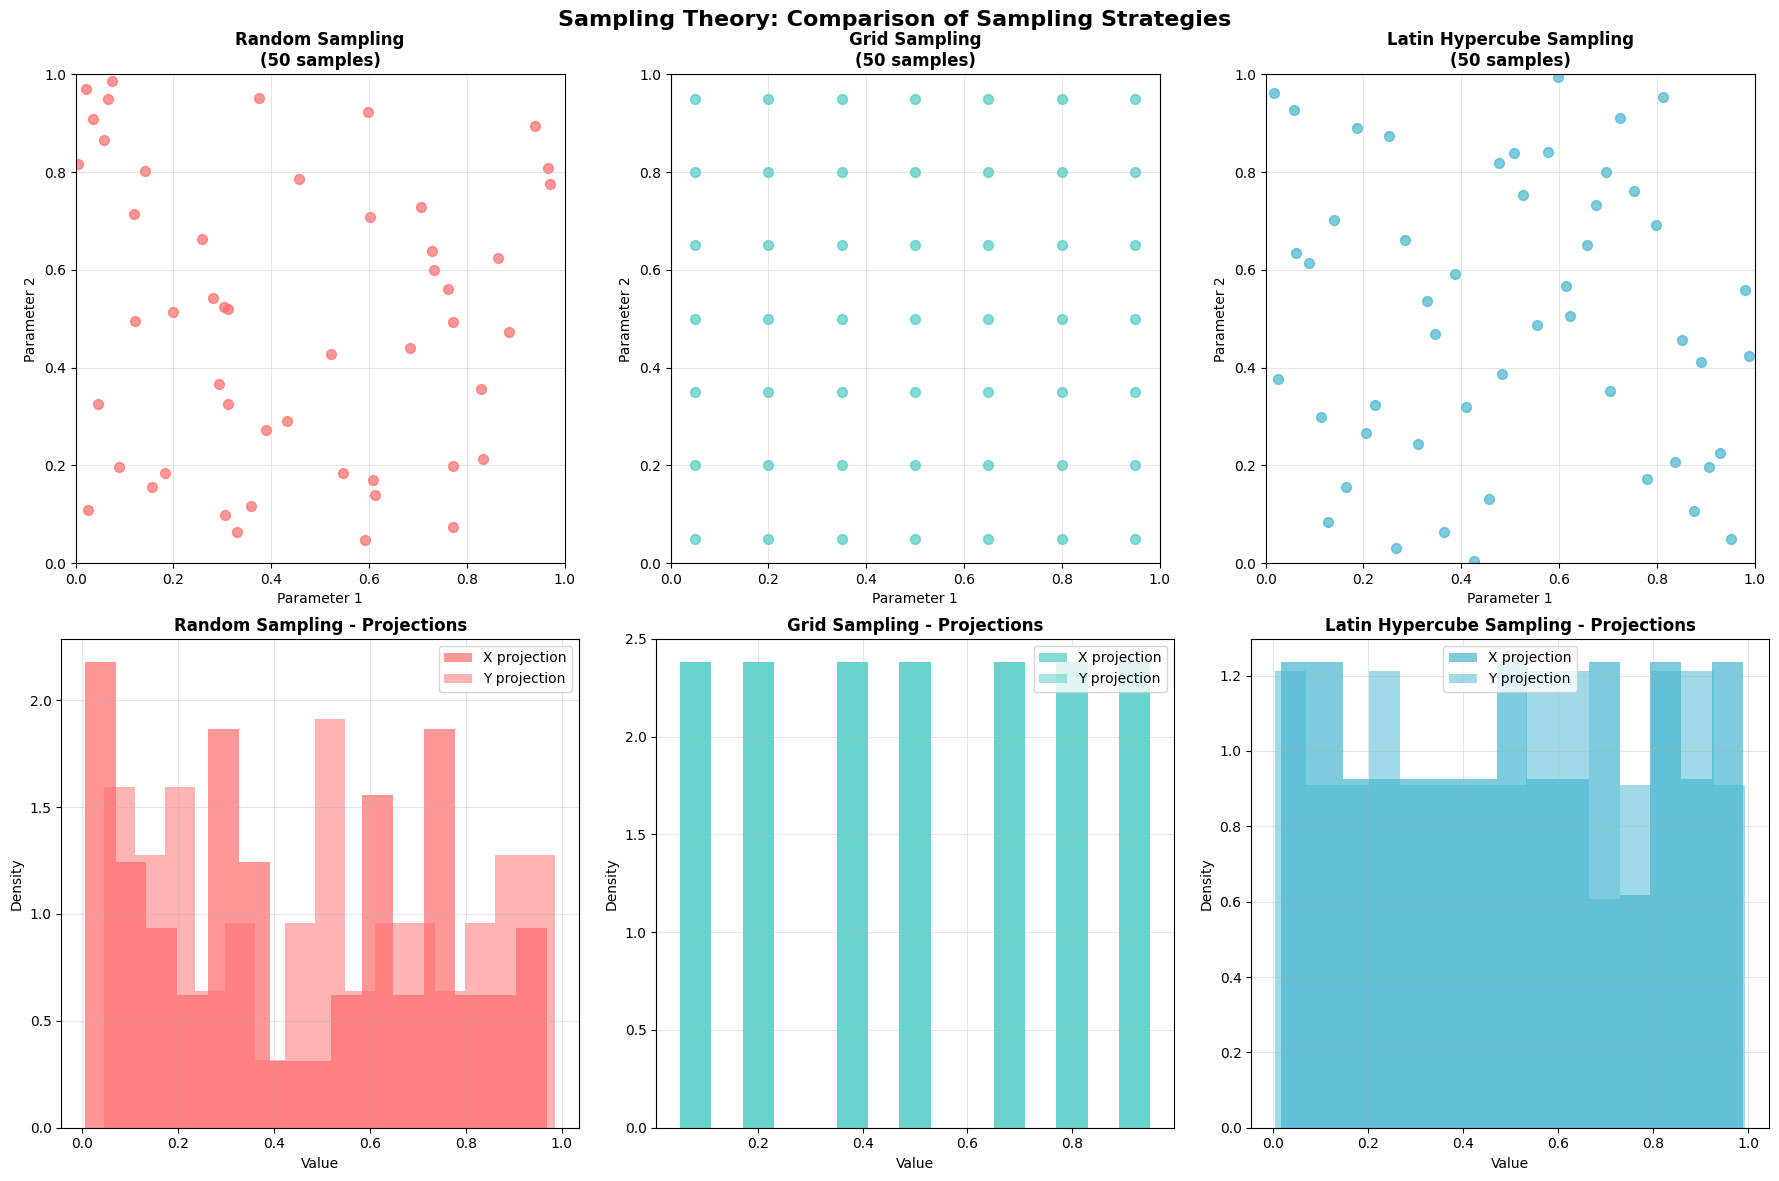

In [2]:
# Demonstration of sampling theory concepts
def demonstrate_sampling_theory():
    """Visualize different sampling strategies and their properties"""

    # Set random seed for reproducibility
    np.random.seed(42)

    # Define 2D parameter space
    n_samples = 50
    bounds = np.array([[0, 1], [0, 1]])

    # 1. Random sampling
    random_samples = np.random.uniform(0, 1, (n_samples, 2))

    # 2. Grid sampling
    grid_size = int(np.sqrt(n_samples))
    x_grid = np.linspace(0.05, 0.95, grid_size)
    y_grid = np.linspace(0.05, 0.95, grid_size)
    grid_samples = np.array(list(itertools.product(x_grid, y_grid)))
    grid_samples = grid_samples[:n_samples]  # Take exactly n_samples

    # 3. Latin Hypercube Sampling
    sampler = qmc.LatinHypercube(d=2, seed=42)
    lhd_samples = sampler.random(n=n_samples)

    # Calculate coverage metrics
    def calculate_coverage_metrics(samples, name):
        """Calculate various coverage metrics for sampling"""
        # Minimum distance between points
        distances = pdist(samples)
        min_distance = np.min(distances)
        mean_distance = np.mean(distances)

        # Space-filling criterion (maximin)
        maxmin_distance = min_distance

        # Uniformity of projections (standard deviation of projections)
        proj_x_std = np.std(np.histogram(samples[:, 0], bins=10)[0])
        proj_y_std = np.std(np.histogram(samples[:, 1], bins=10)[0])

        print(f"{name} Metrics:")
        print(f"  Min distance: {min_distance:.4f}")
        print(f"  Mean distance: {mean_distance:.4f}")
        print(f"  X-projection std: {proj_x_std:.2f}")
        print(f"  Y-projection std: {proj_y_std:.2f}")
        print()

        return {
            'min_distance': min_distance,
            'mean_distance': mean_distance,
            'proj_uniformity': proj_x_std + proj_y_std
        }

    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Sampling Theory: Comparison of Sampling Strategies',
                 fontsize=16, fontweight='bold')

    sampling_methods = [
        (random_samples, 'Random Sampling'),
        (grid_samples, 'Grid Sampling'),
        (lhd_samples, 'Latin Hypercube Sampling')
    ]

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    for idx, (samples, name) in enumerate(sampling_methods):
        # Plot sampling pattern
        axes[0, idx].scatter(samples[:, 0], samples[:, 1],
                           c=colors[idx], alpha=0.7, s=50)
        axes[0, idx].set_xlim(0, 1)
        axes[0, idx].set_ylim(0, 1)
        axes[0, idx].set_title(f'{name}\n({n_samples} samples)', fontweight='bold')
        axes[0, idx].set_xlabel('Parameter 1')
        axes[0, idx].set_ylabel('Parameter 2')
        axes[0, idx].grid(True, alpha=0.3)
        axes[0, idx].set_aspect('equal')

        # Plot projections
        axes[1, idx].hist(samples[:, 0], bins=15, alpha=0.7, color=colors[idx],
                        label='X projection', density=True)
        axes[1, idx].hist(samples[:, 1], bins=15, alpha=0.5, color=colors[idx],
                        label='Y projection', density=True)
        axes[1, idx].set_title(f'{name} - Projections', fontweight='bold')
        axes[1, idx].set_xlabel('Value')
        axes[1, idx].set_ylabel('Density')
        axes[1, idx].legend()
        axes[1, idx].grid(True, alpha=0.3)

        # Calculate and print metrics
        calculate_coverage_metrics(samples, name)

    plt.tight_layout()
    plt.show()

demonstrate_sampling_theory()

## Latin Hypercube Sampling: Theory and Implementation

### 1. Mathematical Foundation

**Latin Hypercube Sampling (LHS)** is a stratified sampling method that ensures uniform coverage of each parameter dimension {cite}`mckay2000comparison`. For $n$ samples in $d$ dimensions:

**Algorithm Steps**:

1. Divide each dimension into $n$ equal intervals: $[0,1/n), [1/n,2/n), \ldots, [(n-1)/n,1]$
2. Randomly select one point from each interval in each dimension
3. Randomly permute the order to avoid correlation between dimensions

**Mathematical Properties**:

- **Unbiased**: $\mathbb{E}[f(\mathbf{X})] = \int_0^1 f(\mathbf{x}) d\mathbf{x}$
- **Lower Variance**: $\text{Var}[\hat{\mu}_{LHS}] \leq \text{Var}[\hat{\mu}_{MC}]$ {cite}`mckay2000comparison`
- **Perfect Projection**: Each 1D projection has exactly one sample per interval

### 2. Error Analysis

The integration error for LHS with smooth functions is:

$$|\mathbb{E}[f(\mathbf{X})] - \hat{\mu}_{LHS}| = O(n^{-1})$$

compared to Monte Carlo's $O(n^{-1/2})$ convergence rate {cite}`bergstra2012random`.

### 3. Optimality Criteria

**Maximin Design** {cite}`mitchell2010hp`: Maximize the minimum distance between any two points:

$$\max_{\mathbf{X}} \min_{i \neq j} d(\mathbf{x}_i, \mathbf{x}_j)$$

**Minimum Correlation**: Minimize correlation between dimensions:

$$\min_{\mathbf{X}} \sum_{i \neq j} |\rho_{ij}|$$

In [3]:
# Implementation of Latin Hypercube Sampling with optimization
class OptimalLatinHypercube:
    """Optimized Latin Hypercube Sampling implementation"""

    def __init__(self, d, n_samples, seed=42):
        self.d = d  # dimensions
        self.n_samples = n_samples
        self.seed = seed
        np.random.seed(seed)

    def generate_initial(self):
        """Generate initial Latin Hypercube design"""
        # Create base Latin Hypercube
        lhd = np.zeros((self.n_samples, self.d))

        for j in range(self.d):
            # Random permutation for each dimension
            perm = np.random.permutation(self.n_samples)
            # Add random offset within each interval
            lhd[:, j] = (perm + np.random.uniform(0, 1, self.n_samples)) / self.n_samples

        return lhd

    def maximin_optimization(self, initial_design, iterations=100):
        """Optimize design using maximin criterion"""
        design = initial_design.copy()
        best_design = design.copy()
        best_min_dist = self._calculate_min_distance(design)

        for iteration in range(iterations):
            # Random elementwise perturbation
            i, j = np.random.randint(0, self.n_samples), np.random.randint(0, self.d)

            # Try swapping with another point in the same dimension
            k = np.random.randint(0, self.n_samples)
            if k != i:
                # Swap positions
                design[i, j], design[k, j] = design[k, j], design[i, j]

                # Calculate new minimum distance
                new_min_dist = self._calculate_min_distance(design)

                # Accept if better
                if new_min_dist > best_min_dist:
                    best_min_dist = new_min_dist
                    best_design = design.copy()
                else:
                    # Revert if not better
                    design[i, j], design[k, j] = design[k, j], design[i, j]

        return best_design

    def _calculate_min_distance(self, design):
        """Calculate minimum distance between any two points"""
        distances = pdist(design)
        return np.min(distances)

    def generate_optimal(self, iterations=100):
        """Generate optimized Latin Hypercube design"""
        initial = self.generate_initial()
        optimal = self.maximin_optimization(initial, iterations)
        return optimal

# Demonstrate LHS optimization
def demonstrate_lhs_optimization():
    """Show the optimization process for Latin Hypercube Sampling"""

    d, n = 2, 20

    # Generate different LHS designs
    generator = OptimalLatinHypercube(d, n, seed=42)

    # Initial LHS
    initial_design = generator.generate_initial()

    # Optimized LHS
    optimized_design = generator.generate_optimal(iterations=200)

    # Regular LHS from scipy
    sampler = qmc.LatinHypercube(d=2, seed=42)
    scipy_lhd = sampler.random(n=n)

    # Calculate metrics
    def calculate_metrics(design, name):
        distances = pdist(design)
        min_dist = np.min(distances)
        mean_dist = np.mean(distances)

        # Calculate correlation between dimensions
        correlation = np.corrcoef(design[:, 0], design[:, 1])[0, 1]

        print(f"{name}:")
        print(f"  Min distance: {min_dist:.4f}")
        print(f"  Mean distance: {mean_dist:.4f}")
        print(f"  Correlation: {correlation:.4f}")
        print()

        return min_dist, mean_dist, correlation

    print("Latin Hypercube Optimization Results:")
    print("=" * 50)

    initial_metrics = calculate_metrics(initial_design, "Initial LHS")
    optimized_metrics = calculate_metrics(optimized_design, "Optimized LHS (Maximin)")
    scipy_metrics = calculate_metrics(scipy_lhd, "SciPy LHS")

demonstrate_lhs_optimization()

Latin Hypercube Optimization Results:
Initial LHS:
  Min distance: 0.0467
  Mean distance: 0.5435
  Correlation: -0.4052

Optimized LHS (Maximin):
  Min distance: 0.1481
  Mean distance: 0.5538
  Correlation: -0.2405

SciPy LHS:
  Min distance: 0.0758
  Mean distance: 0.5406
  Correlation: 0.1101



## Summary

This notebook provides comprehensive foundations for the data pipeline used in magnetic field prediction with deep learning. The key concepts covered include:

**Theoretical Foundations**:
1. **Optimal Experimental Design**: Mathematical framework for sample selection
2. **Latin Hypercube Sampling**: Efficient stratified sampling for high-dimensional spaces
3. **Space-Filling Criteria**: Maximizing coverage and minimizing correlation

**Electromagnetic Problems**:
1. **Coil (Simple)**: 3 parameters, copper in air
2. **Transformer (Medium)**: 4 parameters, M19 core with copper windings
3. **IPM Motor (Complex)**: 5 parameters, M19 core with NdFeBr magnets

**Dataset Specifications**:
- Total samples: 45,000
- Training: 30,000 (67%)
- Validation: 10,000 (22%)
- Test: 5,000 (11%)
- Sampling method: Latin Hypercube for uniform parameter space coverage

**Key Insights**:

The Latin Hypercube Sampling approach ensures:
- No clustering of samples in parameter space
- Each dimension is uniformly represented
- Better convergence than random sampling ($O(n^{-1})$ vs $O(n^{-1/2})$)
- Efficient exploration of high-dimensional design spaces

This theoretical foundation and practical parameterization enable training of deep learning models that accurately predict magnetic fields across diverse electromagnetic device configurations.